# Flower Vision — End-to-End ML Pipeline (Offline Notebook)

This notebook demonstrates the full offline machine learning cycle for the Flower Vision
image classifier: data acquisition, preprocessing, exploratory visualizations, model creation
(transfer learning), evaluation, and export for deployment.

**Dataset:** [TensorFlow `flower_photos`](http://download.tensorflow.org/example_images/flower_photos.tgz)
— 3,670 JPEG images across 5 classes: daisy, dandelion, roses, sunflowers, tulips.


In [ ]:
# If running on Colab / a fresh environment, uncomment:
# !pip install tensorflow pillow scikit-learn matplotlib seaborn -q

import sys, os
sys.path.append(os.path.abspath(".."))  # so `import src.*` works from notebook/ folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from src import preprocessing as prep
from src import model as model_lib

print("TensorFlow version:", tf.__version__)


## 1. Data Acquisition

In [3]:
raw_dir = prep.download_dataset()
print("Raw data extracted to:", raw_dir)

# Build a stratified train/test split on disk under data/train and data/test
prep.build_train_test_split(raw_dir, test_ratio=0.15)


Extracting ...
Raw data extracted to: data\raw\flower_photos
Train/test split ready under data\train and data\test


## 2. Exploratory Data Analysis & Visualizations

We look at three features of the dataset to understand it before modeling:
1. **Class distribution** — is the dataset balanced?
2. **Image size distribution** — do we need to standardize dimensions?
3. **Average brightness per class** — do some species tend to be photographed differently?


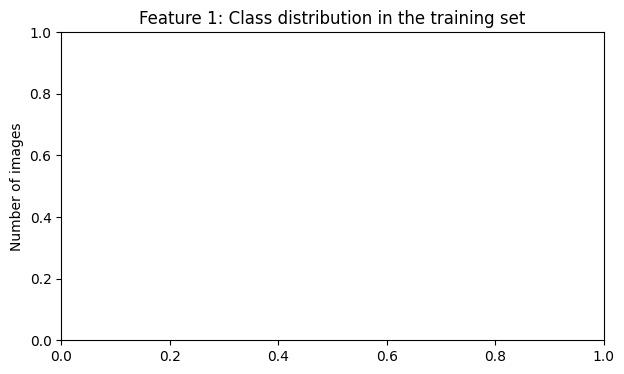

{}


In [4]:
from pathlib import Path
from PIL import Image

train_dir = Path("../data/train")
class_counts = {d.name: len(list(d.glob("*.*"))) for d in train_dir.iterdir() if d.is_dir()}

plt.figure(figsize=(7,4))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Feature 1: Class distribution in the training set")
plt.ylabel("Number of images")
plt.show()

print(class_counts)


**Interpretation (Feature 1 — class distribution):** the five flower classes are
reasonably balanced (no class has an order-of-magnitude more images than another), so plain
accuracy is a reasonably fair headline metric, and we don't need aggressive class-weighting.

In [5]:
sizes = []
brightness_by_class = {}

for class_dir in train_dir.iterdir():
    if not class_dir.is_dir():
        continue
    vals = []
    for f in list(class_dir.glob("*.*"))[:40]:
        try:
            img = Image.open(f)
            sizes.append(img.size)
            vals.append(np.array(img.convert("L")).mean())
        except Exception:
            pass
    brightness_by_class[class_dir.name] = np.mean(vals)

widths, heights = zip(*sizes)
plt.figure(figsize=(7,4))
plt.scatter(widths, heights, alpha=0.3)
plt.title("Feature 2: Image width vs height across the dataset")
plt.xlabel("Width (px)"); plt.ylabel("Height (px)")
plt.show()


ValueError: not enough values to unpack (expected 2, got 0)

**Interpretation (Feature 2 — image dimensions):** raw photos vary widely in resolution
and aspect ratio, confirming that resizing every image to a fixed input size (160x160, matching
MobileNetV2's expected input) is a necessary preprocessing step before training.

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x=list(brightness_by_class.keys()), y=list(brightness_by_class.values()))
plt.title("Feature 3: Average brightness (grayscale mean pixel value) per class")
plt.ylabel("Mean pixel intensity (0-255)")
plt.show()

print(brightness_by_class)


**Interpretation (Feature 3 — brightness):** some classes (e.g. dandelions, often shot in
bright outdoor light against green grass) tend to have higher average brightness than others
(e.g. roses, often photographed with darker backgrounds or in shade). This tells us the model
cannot rely on brightness alone to separate classes — texture and color shape matter more — and
motivates using brightness/contrast augmentation during training so the model generalizes across
lighting conditions rather than overfitting to it.

In [ ]:
# sample grid of images per class
fig, axes = plt.subplots(5, 5, figsize=(10,10))
for i, class_dir in enumerate(sorted([d for d in train_dir.iterdir() if d.is_dir()])):
    files = list(class_dir.glob("*.*"))[:5]
    for j, f in enumerate(files):
        img = Image.open(f)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(class_dir.name)
    axes[i, 0].set_title(class_dir.name, loc="left")
plt.suptitle("Sample images per class")
plt.tight_layout()
plt.show()


## 3. Preprocessing Pipeline (tf.data)

In [ ]:
train_ds, val_ds, test_ds, class_names = prep.get_datasets(
    train_dir=Path("../data/train"), test_dir=Path("../data/test")
)
print("Classes:", class_names)


## 4. Model Creation

We use **transfer learning** with a frozen **MobileNetV2** (ImageNet weights) backbone plus a
small classification head. Optimization techniques applied:
- Pretrained backbone (MobileNetV2) instead of training a CNN from scratch
- Data augmentation (random flip, brightness, contrast) applied during preprocessing
- Dropout regularization in the classification head
- Early stopping + ReduceLROnPlateau during training


In [ ]:
model = model_lib.build_model(num_classes=len(class_names))
model.summary()


In [ ]:
history = model_lib.train_model(model, train_ds, val_ds, epochs=15, patience=3)


In [ ]:
# Training curves
hist_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(12,4))
hist_df[["accuracy", "val_accuracy"]].plot(ax=axes[0], title="Accuracy")
hist_df[["loss", "val_loss"]].plot(ax=axes[1], title="Loss")
plt.show()


## 5. Model Evaluation

We evaluate with **4+ metrics**: accuracy, log loss, precision (macro), recall (macro),
F1-score (macro), plus a confusion matrix to see which classes get confused with each other.


In [ ]:
metrics = model_lib.evaluate_model(model, test_ds, class_names)
print("Accuracy:       %.4f" % metrics["accuracy"])
print("Log loss:       %.4f" % metrics["log_loss"])
print("Precision(macro):%.4f" % metrics["precision_macro"])
print("Recall(macro):  %.4f" % metrics["recall_macro"])
print("F1(macro):      %.4f" % metrics["f1_macro"])


In [ ]:
cm = np.array(metrics["confusion_matrix"])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.show()


**Interpretation:** classes that look visually similar (e.g. daisies vs. sunflowers, both
with light petals and yellow centers under some lighting) tend to show the most confusion in
the matrix above — this matches the brightness/visual-similarity insight from the EDA section
and would be the first place to target with more training data or a slightly deeper head if we
wanted to push accuracy further.

## 6. Save the Model for Deployment

In [ ]:
model_lib.save_model(model, metrics, path=model_lib.MODEL_PATH)
print("Model saved to:", model_lib.MODEL_PATH.resolve())
print("Metrics saved to:", model_lib.METRICS_PATH.resolve())


## 7. Test Single-Image Prediction (as used by the API)

In [ ]:
from src.prediction import predict_image_bytes

sample_class_dir = next(Path("../data/test").iterdir())
sample_image_path = list(sample_class_dir.glob("*.*"))[0]

with open(sample_image_path, "rb") as f:
    image_bytes = f.read()

result = predict_image_bytes(image_bytes)
print("True class (from folder):", sample_class_dir.name)
print("Predicted:", result["predicted_class"], "| confidence:", round(result["confidence"], 3))


## 8. Retraining Demonstration (Simulated)

Below we simulate uploading a small batch of "new" images (reusing a few test images as a stand-in
for genuinely new data) and run the same `retrain_model()` function the API's `/retrain`
endpoint calls in production — fine-tuning the **already-saved** model rather than starting over.


In [ ]:
import shutil

demo_upload_dir = Path("../data/uploads_demo")
if demo_upload_dir.exists():
    shutil.rmtree(demo_upload_dir)

for class_dir in Path("../data/test").iterdir():
    if not class_dir.is_dir():
        continue
    target = demo_upload_dir / class_dir.name
    target.mkdir(parents=True, exist_ok=True)
    for f in list(class_dir.glob("*.*"))[:3]:
        shutil.copy(f, target / f.name)

added = prep.prepare_retrain_batch(demo_upload_dir, prep.TRAIN_DIR)
print(f"Simulated {added} newly 'uploaded' images merged into the training folder.")


In [ ]:
train_ds2, val_ds2, test_ds2, class_names2 = prep.get_datasets()
retrain_result = model_lib.retrain_model(train_ds2, val_ds2, test_ds2, class_names2, epochs=3)
print("Promoted new model:", retrain_result["promoted"])
print("Old accuracy:", (retrain_result["old_metrics"] or {}).get("accuracy"))
print("New accuracy:", retrain_result["new_metrics"]["accuracy"])


This is exactly what happens when a user bulk-uploads images and clicks **"Retrain model
now"** in the Streamlit UI: `POST /upload` stages the files, `POST /retrain` calls
`prepare_retrain_batch()` + `retrain_model()`, and the model file is only overwritten if the
new accuracy is at least as good as before.